# 02 — Data Acquisition & Exploratory Data Analysis

This notebook downloads the CFPB Consumer Complaint Database, profiles every column, and performs a thorough EDA to inform modelling decisions in later notebooks. Every visualisation and statistic here directly supports the rubric criteria for **Use Case & Impact** (understanding the problem domain), **Evaluation** (class-imbalance awareness, reward-signal design), and **Technical Challenge** (temporal drift, text-length budgeting, multi-task target selection).

**Data source:** [CFPB Consumer Complaint Database](https://www.consumerfinance.gov/data-research/consumer-complaints/) — US Government, public domain.

**IMPORTANT — Column naming:** The CFPB CSV uses Title Case with spaces (e.g. `Date received`, `Sub-product`). We rename to snake_case immediately after loading for cleaner code downstream.

In [1]:
import os, sys, zipfile, warnings, string, re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from tqdm.auto import tqdm
import requests
from sklearn.feature_extraction.text import CountVectorizer

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Paths
ROOT = Path('..').resolve()
RAW = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed'
FIG = ROOT / 'reports' / 'figures'
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

print(f'Root: {ROOT}')

Root: C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project


## 2 — Data Acquisition

Download the full CFPB complaint CSV. The zip is ~1.5–1.8 GB; unzipped CSV is ~4–5 GB. Skips if already on disk.

In [2]:
URL = 'https://files.consumerfinance.gov/ccdb/complaints.csv.zip'
ZIP_PATH = RAW / 'complaints.csv.zip'
CSV_PATH = RAW / 'complaints.csv'

if CSV_PATH.exists():
    print(f'CSV already exists at {CSV_PATH} — skipping download.')
else:
    print('Downloading CFPB complaints dataset...')
    try:
        resp = requests.get(URL, stream=True, timeout=30)
        resp.raise_for_status()
        total = int(resp.headers.get('content-length', 0))
        with open(ZIP_PATH, 'wb') as f, tqdm(
            total=total, unit='B', unit_scale=True, desc='complaints.csv.zip'
        ) as bar:
            for chunk in resp.iter_content(chunk_size=1 << 20):
                f.write(chunk)
                bar.update(len(chunk))
        print('Unzipping...')
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(RAW)
        ZIP_PATH.unlink()  # clean up zip
        print(f'Saved to {CSV_PATH}')
    except Exception as e:
        print(f'Download failed: {e}')
        print('Please download manually from:', URL)
        print('Place complaints.csv in:', RAW)

CSV already exists at C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\raw\complaints.csv — skipping download.


In [3]:
# ─── Load with correct CFPB column names (Title Case with spaces) ───
# First, peek at actual column names to confirm
peek = pd.read_csv(CSV_PATH, nrows=2)
print('Actual CSV columns:')
for i, c in enumerate(peek.columns):
    print(f'  {i:2d}: {c!r}')

Actual CSV columns:
   0: 'Date received'
   1: 'Product'
   2: 'Sub-product'
   3: 'Issue'
   4: 'Sub-issue'
   5: 'Consumer complaint narrative'
   6: 'Company public response'
   7: 'Company'
   8: 'State'
   9: 'ZIP code'
  10: 'Tags'
  11: 'Consumer consent provided?'
  12: 'Submitted via'
  13: 'Date sent to company'
  14: 'Company response to consumer'
  15: 'Timely response?'
  16: 'Consumer disputed?'
  17: 'Complaint ID'


In [4]:
# ─── Full load ───
# The CFPB CSV uses Title Case headers like 'Date received', 'Sub-product', etc.
# We load first, then rename to snake_case for clean code.

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Raw shape: {df.shape}')
print(f'Columns:   {list(df.columns)}')

Raw shape: (13906793, 18)
Columns:   ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [5]:
# ─── Rename to snake_case ───
rename_map = {
    'Date received':                 'date_received',
    'Product':                       'product',
    'Sub-product':                   'sub_product',
    'Issue':                         'issue',
    'Sub-issue':                     'sub_issue',
    'Consumer complaint narrative':  'narrative',
    'Company public response':       'company_public_response',
    'Company':                       'company',
    'State':                         'state',
    'ZIP code':                      'zip_code',
    'Tags':                          'tags',
    'Consumer consent provided?':    'consumer_consent',
    'Submitted via':                 'submitted_via',
    'Date sent to company':          'date_sent_to_company',
    'Company response to consumer':  'company_response',
    'Timely response?':              'timely_response',
    'Consumer disputed?':            'consumer_disputed',
    'Complaint ID':                  'complaint_id',
}

df.rename(columns=rename_map, inplace=True)

# Parse dates
df['date_received'] = pd.to_datetime(df['date_received'], errors='coerce')
df['date_sent_to_company'] = pd.to_datetime(df['date_sent_to_company'], errors='coerce')

# Convert low-cardinality columns to category for memory savings
cat_cols = [
    'product', 'sub_product', 'issue', 'sub_issue',
    'company', 'state', 'tags', 'consumer_consent',
    'submitted_via', 'company_response', 'timely_response',
    'consumer_disputed'
]
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

print(f'Shape after rename: {df.shape}')
df.head(3)

Shape after rename: (13906793, 18)


,date_received,product,sub_product,issue,sub_issue,narrative,company_public_response,company,state,zip_code,tags,consumer_consent,submitted_via,date_sent_to_company,company_response,timely_response,consumer_disputed,complaint_id
0,2020-07-06,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,FL,346XX,NaN,Other,Web,2020-07-06,Closed with explanation,Yes,NaN,3730948
1,2019-12-26,Credit card or prepaid card,General-purpose credit card or charge card,"Advertising and marketing, including promotion...",Confusing or misleading advertising about the ...,NaN,NaN,CAPITAL ONE FINANCIAL CORPORATION,CA,94025,NaN,Consent not provided,Web,2019-12-26,Closed with explanation,Yes,NaN,3477549
2,2020-05-08,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Information belongs to someone else,These are not my accounts.,Company has responded to the consumer and the ...,Experian Information Solutions Inc.,NV,89030,NaN,Consent provided,Web,2020-05-08,Closed with explanation,Yes,NaN,3642453


In [6]:
total = len(df)
has_narrative = df['narrative'].notna().sum()
print(f'Total complaints : {total:,}')
print(f'With narrative   : {has_narrative:,} ({has_narrative/total:.1%})')
print(f'Date range       : {df.date_received.min().date()} → {df.date_received.max().date()}')

Total complaints : 13,906,793
With narrative   : 3,740,313 (26.9%)
Date range       : 2011-12-01 → 2026-03-11


## 3 — Basic Dataset Overview

Column types, memory usage, and missing-value profile.

In [7]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13906793 entries, 0 to 13906792
Data columns (total 18 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   date_received            datetime64[ns]
 1   product                  category      
 2   sub_product              category      
 3   issue                    category      
 4   sub_issue                category      
 5   narrative                object        
 6   company_public_response  object        
 7   company                  category      
 8   state                    category      
 9   zip_code                 object        
 10  tags                     category      
 11  consumer_consent         category      
 12  submitted_via            category      
 13  date_sent_to_company     datetime64[ns]
 14  company_response         category      
 15  timely_response          category      
 16  consumer_disputed        category      
 17  complaint_id             

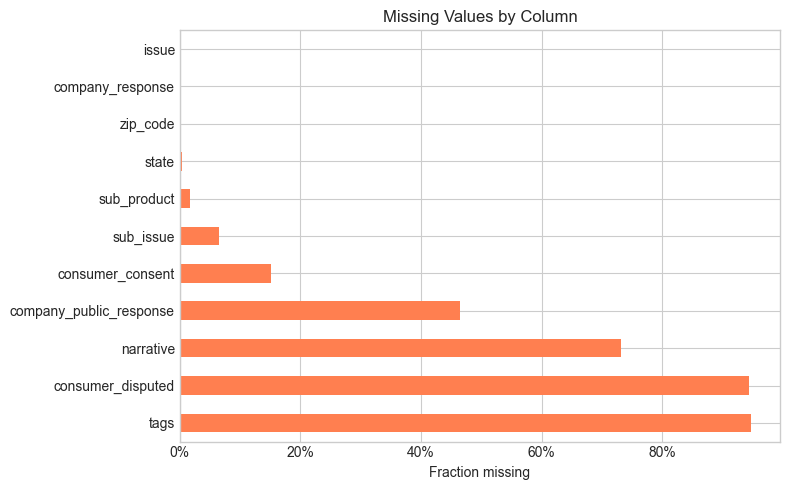

In [8]:
# Missing-value bar chart
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(8, 5))
miss.plot.barh(ax=ax, color='coral')
ax.set_xlabel('Fraction missing')
ax.set_title('Missing Values by Column')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
fig.savefig(FIG / '02_missing_values.png', dpi=150)
plt.show()

In [9]:
# Unique counts per categorical column
print(f'{"Column":40s}  {"Unique":>8s}  {"Missing %":>10s}')
print('-' * 62)
for c in cat_cols + ['zip_code', 'complaint_id']:
    if c in df.columns:
        n_unique = df[c].nunique()
        pct_miss = df[c].isna().mean() * 100
        print(f'{c:40s}  {n_unique:>8,}  {pct_miss:>9.2f}%')

Column                                      Unique   Missing %
--------------------------------------------------------------
product                                         21       0.00%
sub_product                                     86       1.69%
issue                                          178       0.00%
sub_issue                                      272       6.41%
company                                      7,828       0.00%
state                                           63       0.43%
tags                                             3      94.80%
consumer_consent                                 4      15.04%
submitted_via                                    7       0.00%
company_response                                 8       0.00%
timely_response                                  2       0.00%
consumer_disputed                                2      94.48%
zip_code                                    35,963       0.22%
complaint_id                              13,906,793   

## 4 — Sample Narratives Inspection

Before any quantitative analysis, we must actually **read** the data. This reveals the XXXX redaction patterns, emotional tone, financial jargon density, and real-world messiness that will affect tokenisation and model performance.

In [10]:
# Display 5 random narratives (truncated for readability)
sample_narrs = df[df['narrative'].notna()].sample(5, random_state=42)

for i, (_, row) in enumerate(sample_narrs.iterrows(), 1):
    text = str(row['narrative'])[:600]
    print(f'--- Sample {i} | Product: {row["product"]} | Issue: {row["issue"]} ---')
    print(text)
    if len(str(row['narrative'])) > 600:
        print(f'  ... [{len(str(row["narrative"])):,} chars total]')
    print()

--- Sample 1 | Product: Credit card | Issue: Problem with a purchase shown on your statement ---
I purchased an airline ticket back on XX/XX/XXXX, and paid with my Chase Sapphire card. I cancelled the ticket on XX/XX/XXXX and asked for a refund from XXXX. They told me it would take about XXXX  days to effectuate the refund. 
A month later, I created a case with XXXX STILL NO HELP. On XX/XX/XXXX, I got an acknowledgement from XXXX of an issue with their procedures that prevented them from effectuating the refund. Then on XX/XX/XXXX I created a new case request with XXXX. STILL NO HELP. I have created a second case in XXXX - STILL NO HELP. 

I waited for XXXX to rectify the issue. XXXX mont
  ... [955 chars total]

--- Sample 2 | Product: Money transfer, virtual currency, or money service | Issue: Fraud or scam ---
I sold my babys crib on XX/XX/2020. The buyer transferred {$110.00} to my phone number using XXXX XXXX  XXXX XXXX. I received an sms to accept the amount. As my phone number w

**Observations from reading the data:**
- CFPB replaces PII with `XXXX` or `XX` (names, dates, account numbers, dollar amounts)
- Consumers write in highly variable styles: some are brief and factual, others are emotional multi-paragraph essays
- Financial jargon is common (APR, escrow, forbearance, charge-off, garnishment)
- ALL CAPS sections appear when consumers are frustrated
- Some narratives include pasted email threads or letter copies

These observations directly inform the preprocessing pipeline in NB03.

## 5 — Temporal Analysis

Monthly complaint volume to identify trends and temporal-split boundaries.

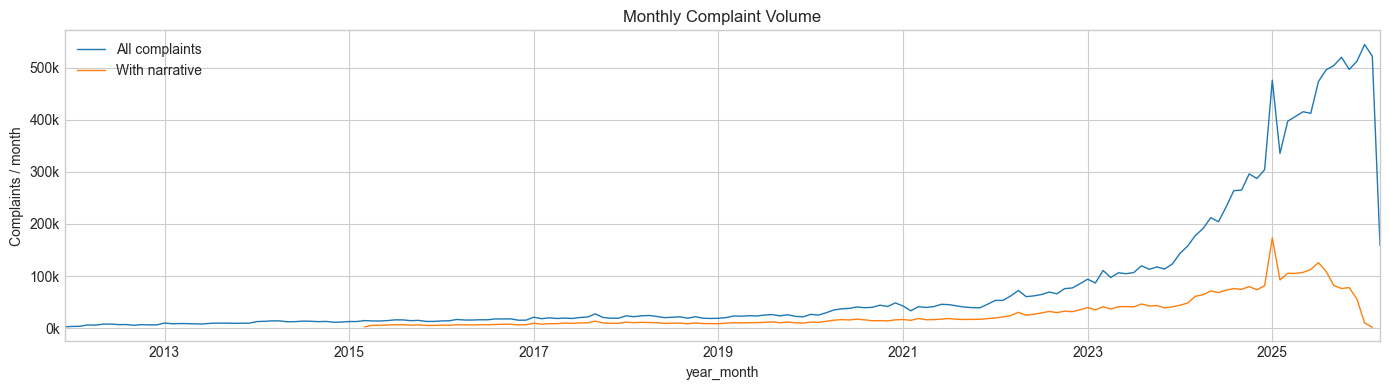

In [11]:
df['year_month'] = df['date_received'].dt.to_period('M')

monthly_all = df.groupby('year_month').size()
monthly_narr = df[df['narrative'].notna()].groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_all.plot(ax=ax, label='All complaints', linewidth=1)
monthly_narr.plot(ax=ax, label='With narrative', linewidth=1)
ax.set_ylabel('Complaints / month')
ax.set_title('Monthly Complaint Volume')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
fig.savefig(FIG / '02_monthly_volume.png', dpi=150)
plt.show()

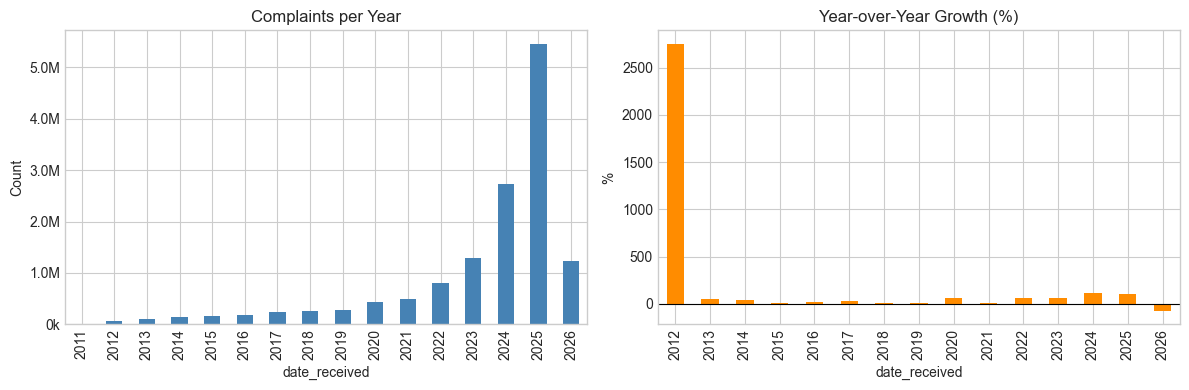

In [12]:
# Year-over-year growth
yearly = df.groupby(df['date_received'].dt.year).size()
yoy = yearly.pct_change().dropna() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
yearly.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Complaints per Year')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1000:.0f}k'))

yoy.plot.bar(ax=axes[1], color='darkorange')
axes[1].set_title('Year-over-Year Growth (%)')
axes[1].set_ylabel('%')
axes[1].axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
fig.savefig(FIG / '02_yoy_growth.png', dpi=150)
plt.show()

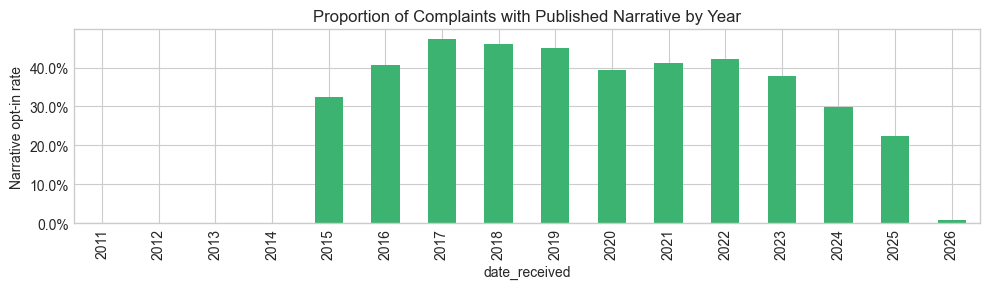

Note: Narratives were first published in March 2015. Pre-2015 complaints have no narratives.


In [13]:
# Narrative opt-in rate over time — does it change?
narr_rate = df.groupby(df['date_received'].dt.year).apply(
    lambda g: g['narrative'].notna().mean()
)

fig, ax = plt.subplots(figsize=(10, 3))
narr_rate.plot.bar(ax=ax, color='mediumseagreen')
ax.set_ylabel('Narrative opt-in rate')
ax.set_title('Proportion of Complaints with Published Narrative by Year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
fig.savefig(FIG / '02_narrative_rate_by_year.png', dpi=150)
plt.show()

print('Note: Narratives were first published in March 2015. Pre-2015 complaints have no narratives.')

## 6 — Product Distribution

Primary classification target. Expect heavy class imbalance with credit-reporting dominating.

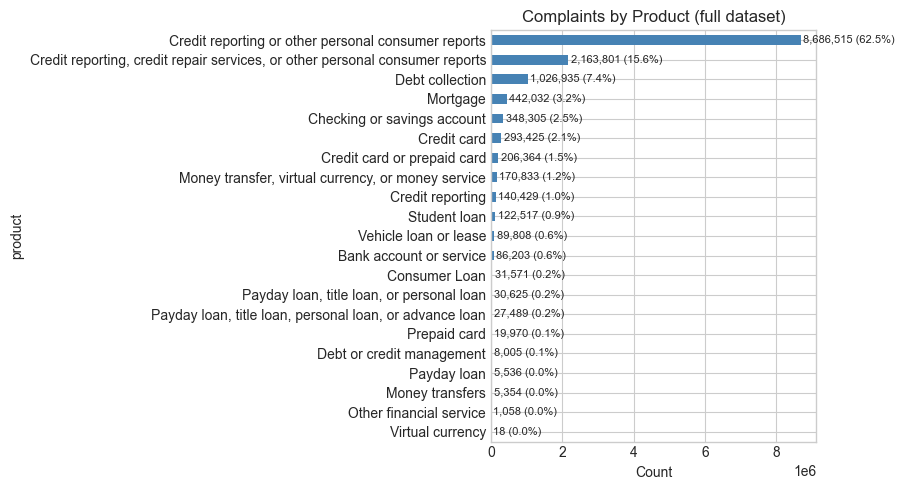

In [14]:
prod_counts = df['product'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
bars = prod_counts.plot.barh(ax=ax, color='steelblue')
for i, (v, pct) in enumerate(zip(prod_counts, prod_counts / total * 100)):
    ax.text(v + total * 0.005, i, f'{v:,} ({pct:.1f}%)', va='center', fontsize=8)
ax.set_xlabel('Count')
ax.set_title('Complaints by Product (full dataset)')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG / '02_product_distribution.png', dpi=150)
plt.show()

In [15]:
# CRITICAL: Product distribution in narrative-only subset vs full dataset
# If these differ, our model trains on a biased sample
narr_mask = df['narrative'].notna()
prod_full_pct = df['product'].value_counts(normalize=True)
prod_narr_pct = df.loc[narr_mask, 'product'].value_counts(normalize=True)

comparison = pd.DataFrame({
    'Full dataset %': (prod_full_pct * 100).round(1),
    'Narrative subset %': (prod_narr_pct * 100).round(1),
}).fillna(0)
comparison['Difference (pp)'] = (comparison['Narrative subset %'] - comparison['Full dataset %']).round(1)
comparison = comparison.sort_values('Full dataset %', ascending=False)

print('Product distribution: Full dataset vs Narrative-only subset')
print('=' * 65)
print(comparison.to_string())
print()
print('Large differences indicate narrative opt-in bias — certain product')
print('complainants are more/less likely to share their story.')

Product distribution: Full dataset vs Narrative-only subset
                                                                              Full dataset %  Narrative subset %  Difference (pp)
product                                                                                                                          
Credit reporting or other personal consumer reports                                     62.5                44.6            -17.9
Credit reporting, credit repair services, or other personal consumer reports            15.6                21.6              6.0
Debt collection                                                                          7.4                10.9              3.5
Mortgage                                                                                 3.2                 3.7              0.5
Checking or savings account                                                              2.5                 4.6              2.1
Credit card                   

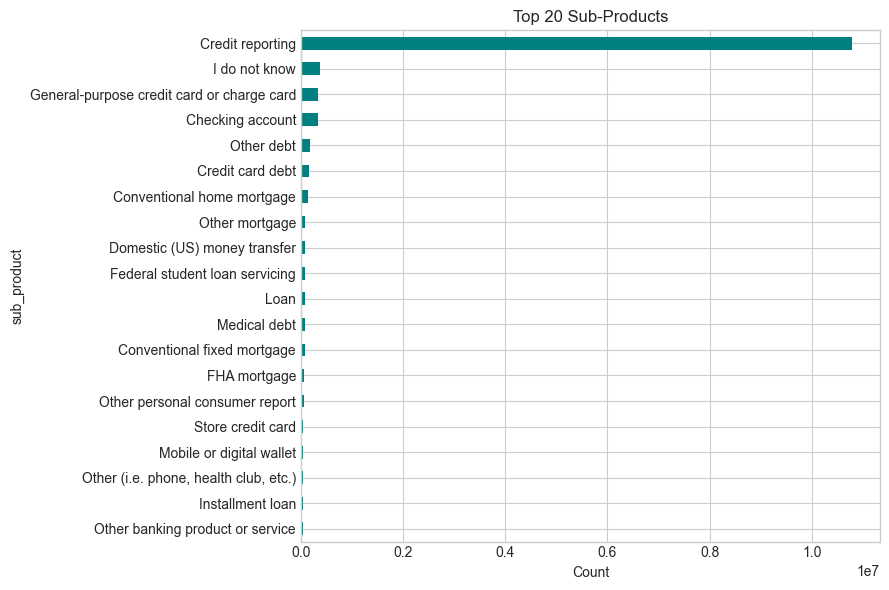

In [16]:
# Top 20 sub-products
sub_counts = df['sub_product'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 6))
sub_counts.plot.barh(ax=ax, color='teal')
ax.set_xlabel('Count')
ax.set_title('Top 20 Sub-Products')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG / '02_sub_product_top20.png', dpi=150)
plt.show()

## 7 — Issue Distribution

Another classification target with a long tail. We quantify how concentrated the distribution is.

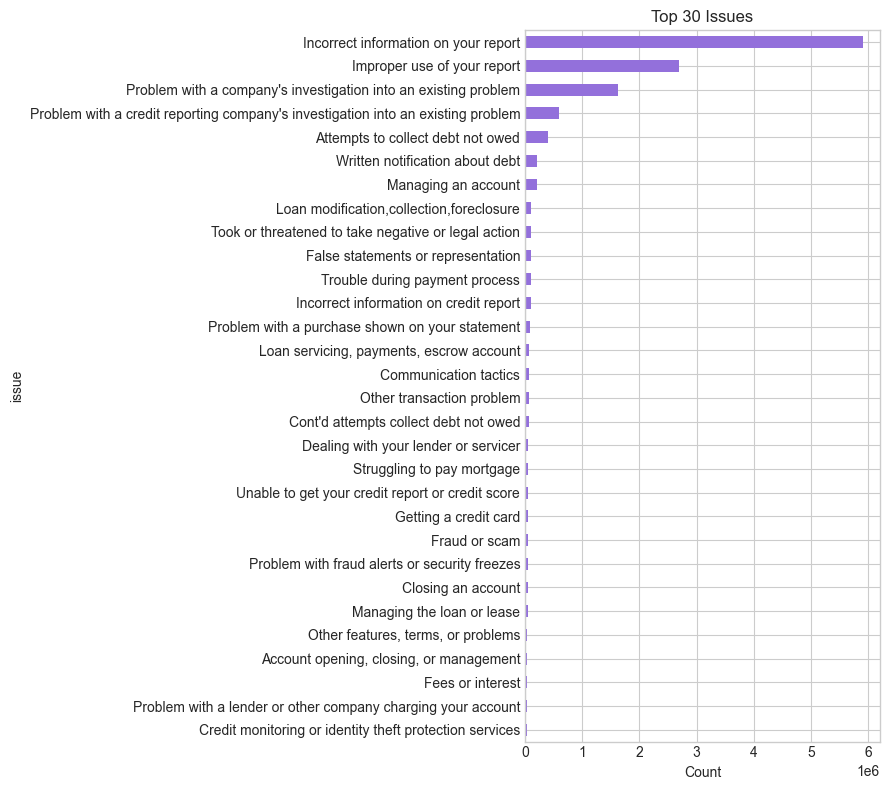

In [17]:
issue_counts = df['issue'].value_counts()

fig, ax = plt.subplots(figsize=(9, 8))
issue_counts.head(30).plot.barh(ax=ax, color='mediumpurple')
ax.set_xlabel('Count')
ax.set_title('Top 30 Issues')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG / '02_issue_top30.png', dpi=150)
plt.show()

In [18]:
# Long-tail: how many issues cover 80% of complaints?
cum = issue_counts.cumsum() / issue_counts.sum()
n80 = (cum <= 0.80).sum() + 1
print(f'{n80} issues (out of {len(issue_counts)}) cover 80% of all complaints.')
print(f'The remaining {len(issue_counts) - n80} issues share the other 20%.')
print(f'\nThis extreme long tail motivates collapsing rare issues into "Other" for classification.')

5 issues (out of 178) cover 80% of all complaints.
The remaining 173 issues share the other 20%.

This extreme long tail motivates collapsing rare issues into "Other" for classification.


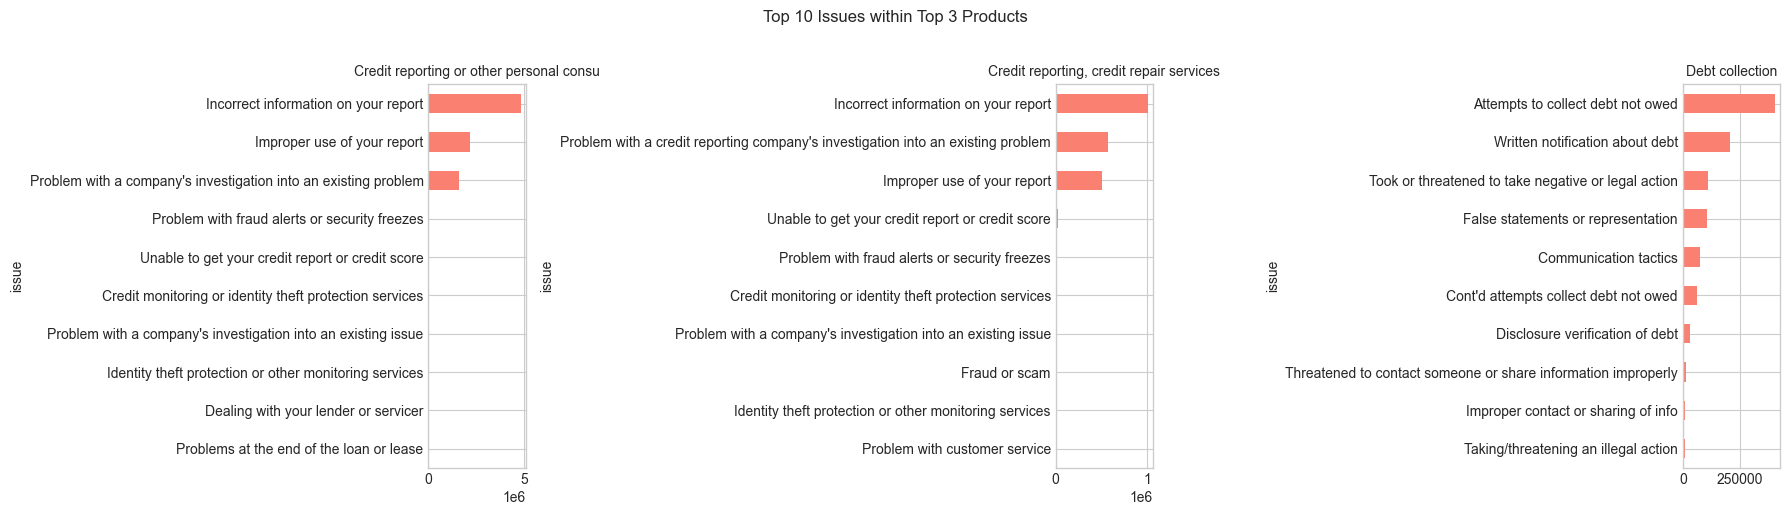

In [19]:
# Issue distribution within top 3 products
top3_prods = prod_counts.index[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, prod in zip(axes, top3_prods):
    sub = df[df['product'] == prod]['issue'].value_counts().head(10)
    sub.plot.barh(ax=ax, color='salmon')
    ax.set_title(str(prod)[:40], fontsize=10)
    ax.invert_yaxis()
plt.suptitle('Top 10 Issues within Top 3 Products', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIG / '02_issue_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 — Company Response Distribution (RL Reward Signal)

These responses become the **reward signal** for the RL routing agent. Understanding their distribution is critical for designing the reward function.

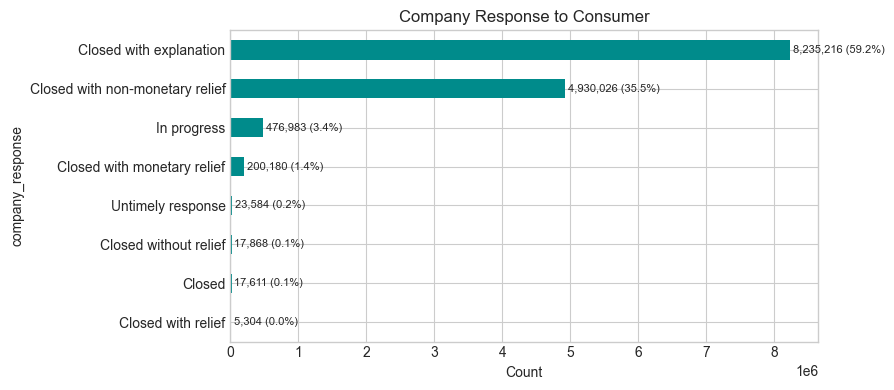

In [20]:
resp_counts = df['company_response'].value_counts()
resp_pct = resp_counts / total * 100

fig, ax = plt.subplots(figsize=(9, 4))
resp_counts.plot.barh(ax=ax, color='darkcyan')
for i, (v, pct) in enumerate(zip(resp_counts, resp_pct)):
    ax.text(v + total * 0.003, i, f'{v:,} ({pct:.1f}%)', va='center', fontsize=8)
ax.set_xlabel('Count')
ax.set_title('Company Response to Consumer')
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG / '02_company_response.png', dpi=150)
plt.show()

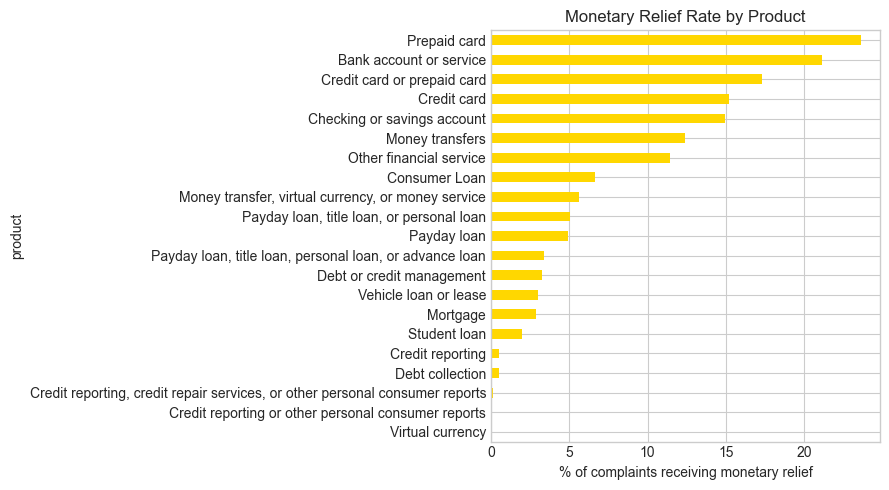

In [21]:
# Cross-tabulation: company_response × product (for RL agent design)
# Monetary relief rates likely vary by product
resp_by_prod = pd.crosstab(
    df['product'], df['company_response'], normalize='index'
) * 100

# Show monetary relief rate by product
monetary_col = [c for c in resp_by_prod.columns if 'monetary' in str(c).lower() and 'non' not in str(c).lower()]
if monetary_col:
    monetary_rate = resp_by_prod[monetary_col[0]].sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    monetary_rate.plot.barh(ax=ax, color='gold')
    ax.set_xlabel('% of complaints receiving monetary relief')
    ax.set_title('Monetary Relief Rate by Product')
    ax.invert_yaxis()
    plt.tight_layout()
    fig.savefig(FIG / '02_monetary_relief_by_product.png', dpi=150)
    plt.show()
else:
    print('Monetary relief column not found — check company_response values:')
    print(resp_counts.index.tolist())

### Reward Mapping for RL Routing Agent

| Response | Reward | Rationale |
|---|---|---|
| Closed with monetary relief | **1.0** | Best consumer outcome |
| Closed with non-monetary relief | **0.75** | Tangible resolution without payment |
| Closed with explanation | **0.3** | Addressed but no concrete relief |
| Closed | **0.2** | Resolved, no detail |
| Untimely response | **0.0** | Regulatory failure |

The dominance of *Closed with explanation* means most complaints receive moderate reward — the agent must learn to distinguish the minority high-reward cases.

In [22]:
# Consumer disputed rate & timely response rate
# NOTE: consumer_disputed was DISCONTINUED on April 24, 2017.
# All post-2017 values are N/A or blank. This field CANNOT be a classification
# target for the full dataset — only for pre-2017 complaints.

disputed_valid = df[df['consumer_disputed'].isin(['Yes', 'No'])]
print(f'Complaints with valid consumer_disputed field: {len(disputed_valid):,}')
print(f'Date range of valid disputes: {disputed_valid["date_received"].min().date()} → {disputed_valid["date_received"].max().date()}')
overall_dispute = (disputed_valid['consumer_disputed'] == 'Yes').mean()
print(f'Overall dispute rate (pre-2017 only): {overall_dispute:.2%}')
print()
print('⚠ consumer_disputed was discontinued April 2017.')
print('  It CANNOT be used as a classification target on post-2017 data.')
print('  We will use company_response + timely_response as our RL signal instead.')

Complaints with valid consumer_disputed field: 768,112
Date range of valid disputes: 2011-12-01 → 2017-04-22
Overall dispute rate (pre-2017 only): 19.32%

⚠ consumer_disputed was discontinued April 2017.
  It CANNOT be used as a classification target on post-2017 data.
  We will use company_response + timely_response as our RL signal instead.


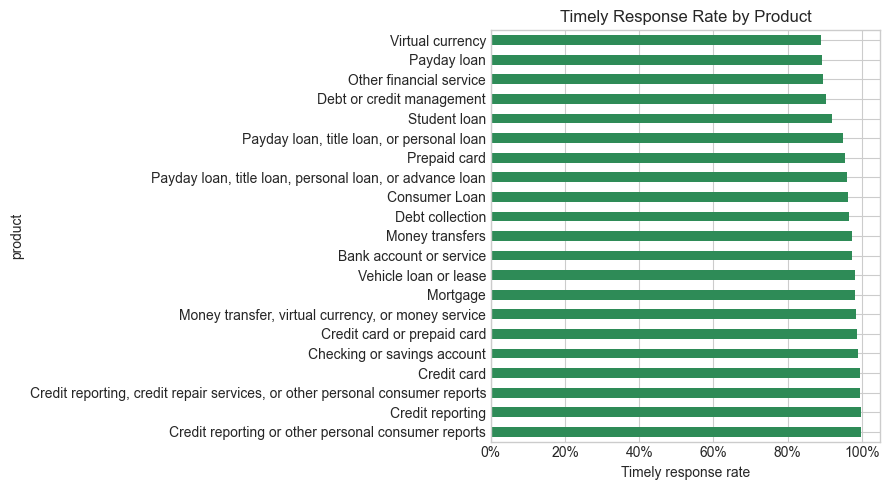

In [23]:
# Timely response rate by product
timely_rate = df.groupby('product').apply(
    lambda g: (g['timely_response'].astype(str) == 'Yes').mean()
).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
timely_rate.plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('Timely response rate')
ax.set_title('Timely Response Rate by Product')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.invert_yaxis()
plt.tight_layout()
fig.savefig(FIG / '02_timely_response_by_product.png', dpi=150)
plt.show()

## 9 — Tags Analysis (Vulnerable Populations)

The `tags` field identifies complaints from **Older Americans** (62+) and **Servicemembers**. These are federally designated vulnerable populations — relevant for our Use Case & Impact rubric criterion.

In [24]:
tags_counts = df['tags'].value_counts(dropna=False)
print('Tags distribution:')
for tag, count in tags_counts.items():
    pct = count / total * 100
    label = str(tag) if pd.notna(tag) else '(no tag)'
    print(f'  {label:30s}  {count:>10,}  ({pct:.1f}%)')

Tags distribution:
  (no tag)                        13,183,662  (94.8%)
  Servicemember                      457,828  (3.3%)
  Older American                     211,161  (1.5%)
  Older American, Servicemember       54,142  (0.4%)


## 10 — Text Length Analysis

Filter to the narrative subset. Character and word-count distributions inform the tokeniser `max_length` budget.

In [25]:
narr = df[df['narrative'].notna()].copy()
narr['char_len'] = narr['narrative'].str.len()
narr['word_count'] = narr['narrative'].str.split().str.len()

print(f'Narrative subset: {len(narr):,} rows')

Narrative subset: 3,740,313 rows


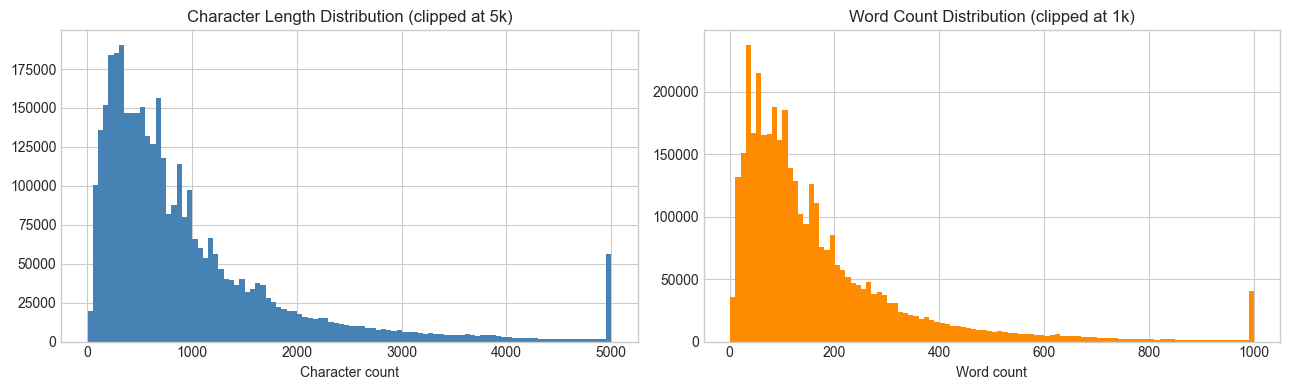

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(narr['char_len'].clip(upper=5000), bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Character count')
axes[0].set_title('Character Length Distribution (clipped at 5k)')

axes[1].hist(narr['word_count'].clip(upper=1000), bins=100, color='darkorange', edgecolor='none')
axes[1].set_xlabel('Word count')
axes[1].set_title('Word Count Distribution (clipped at 1k)')

plt.tight_layout()
fig.savefig(FIG / '02_text_length_dist.png', dpi=150)
plt.show()

In [27]:
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
stats = narr['word_count'].describe(percentiles=percentiles)
print('Word-count statistics:')
print(stats.to_string())
print(f'\nMean chars: {narr["char_len"].mean():.0f}, Median chars: {narr["char_len"].median():.0f}')
print(f'\n--- Max-length recommendation ---')
p90 = narr['word_count'].quantile(0.90)
p95 = narr['word_count'].quantile(0.95)
print(f'90th percentile: {p90:.0f} words ≈ {p90 * 1.3:.0f} subword tokens')
print(f'95th percentile: {p95:.0f} words ≈ {p95 * 1.3:.0f} subword tokens')
print(f'Recommendation: max_length=512 captures ~90th percentile with minimal truncation.')

Word-count statistics:
count    3.740313e+06
mean     1.763317e+02
std      2.228389e+02
min      1.000000e+00
25%      6.000000e+01
50%      1.160000e+02
75%      2.110000e+02
90%      3.650000e+02
95%      5.160000e+02
99%      1.020000e+03
max      6.469000e+03

Mean chars: 1014, Median chars: 662

--- Max-length recommendation ---
90th percentile: 365 words ≈ 474 subword tokens
95th percentile: 516 words ≈ 671 subword tokens
Recommendation: max_length=512 captures ~90th percentile with minimal truncation.


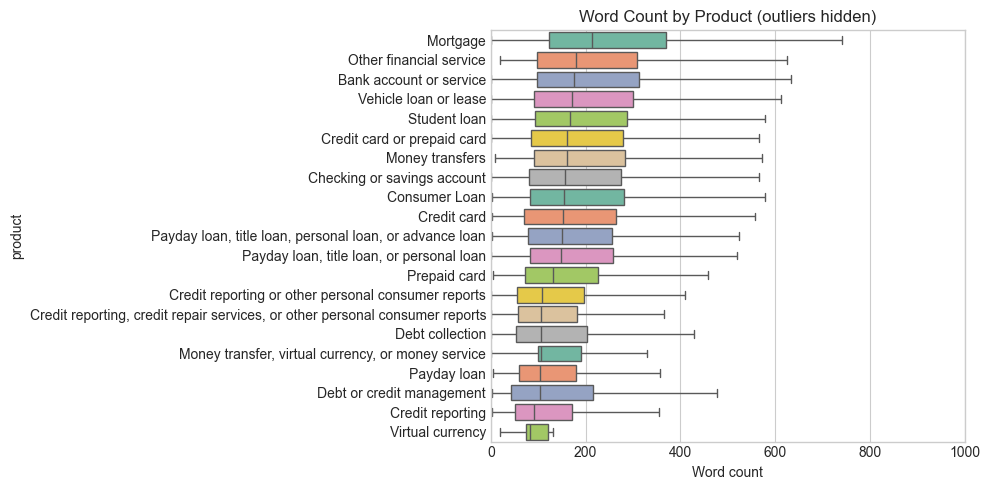

In [28]:
# Word count by product
fig, ax = plt.subplots(figsize=(10, 5))
order = narr.groupby('product')['word_count'].median().sort_values(ascending=False).index
sns.boxplot(
    data=narr, y='product', x='word_count', order=order,
    ax=ax, showfliers=False, palette='Set2'
)
ax.set_xlim(0, 1000)
ax.set_xlabel('Word count')
ax.set_title('Word Count by Product (outliers hidden)')
plt.tight_layout()
fig.savefig(FIG / '02_wordcount_by_product.png', dpi=150)
plt.show()

## 11 — XXXX Placeholder Analysis

CFPB redacts PII with `XXXX`. Frequency varies by product (e.g., debt collection references more personal info).

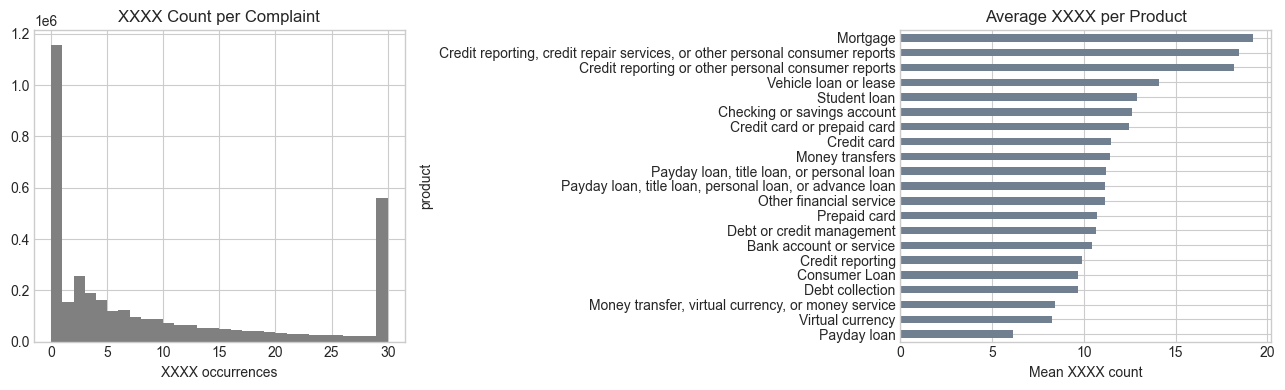

Mean XXXX per complaint: 16.1
Complaints with zero XXXX: 30.9%


In [29]:
# NOTE: Use raw string r'\bX{2,}\b' — single backslash for regex word boundary
narr['xxxx_count'] = narr['narrative'].str.count(r'\bX{2,}\b')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(narr['xxxx_count'].clip(upper=30), bins=30, color='gray', edgecolor='none')
axes[0].set_xlabel('XXXX occurrences')
axes[0].set_title('XXXX Count per Complaint')

avg_xx = narr.groupby('product')['xxxx_count'].mean().sort_values(ascending=False)
avg_xx.plot.barh(ax=axes[1], color='slategray')
axes[1].set_xlabel('Mean XXXX count')
axes[1].set_title('Average XXXX per Product')
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(FIG / '02_xxxx_analysis.png', dpi=150)
plt.show()

print(f'Mean XXXX per complaint: {narr["xxxx_count"].mean():.1f}')
print(f'Complaints with zero XXXX: {(narr["xxxx_count"] == 0).mean():.1%}')

## 12 — Duplicate Detection

With millions of rows, exact or near-duplicate narratives are likely (resubmissions, template complaints from law firms).

In [30]:
# Exact duplicate narratives
n_dup_exact = narr['narrative'].duplicated().sum()
print(f'Exact duplicate narratives: {n_dup_exact:,} ({n_dup_exact / len(narr):.2%} of narrative subset)')

# Show a few duplicates
dup_texts = narr[narr['narrative'].duplicated(keep=False)]['narrative'].value_counts().head(5)
print(f'\nTop 5 most-duplicated narratives (occurrence count):')
for text, count in dup_texts.items():
    print(f'  {count:>5} times: "{str(text)[:100]}..."')

print(f'\n→ Will deduplicate in NB03 preprocessing to prevent data leakage.')

Exact duplicate narratives: 1,243,659 (33.25% of narrative subset)

Top 5 most-duplicated narratives (occurrence count):
  27490 times: "In accordance with the Fair Credit Reporting act. The List of accounts below has violated my federal..."
  24182 times: "My credit reports are inaccurate. These inaccuracies are causing creditors to deny me credit. You ha..."
  18334 times: "You have reported inaccurate and unauthorized accounts on my credit report, which is a violation of ..."
  15803 times: "Upon reviewing my credit report, I have identified inaccurate accounts that need reporting and corre..."
  12204 times: "I am writing to have the following information removed from my credit file, the items that I need de..."

→ Will deduplicate in NB03 preprocessing to prevent data leakage.


## 13 — Submission Channel & Geography

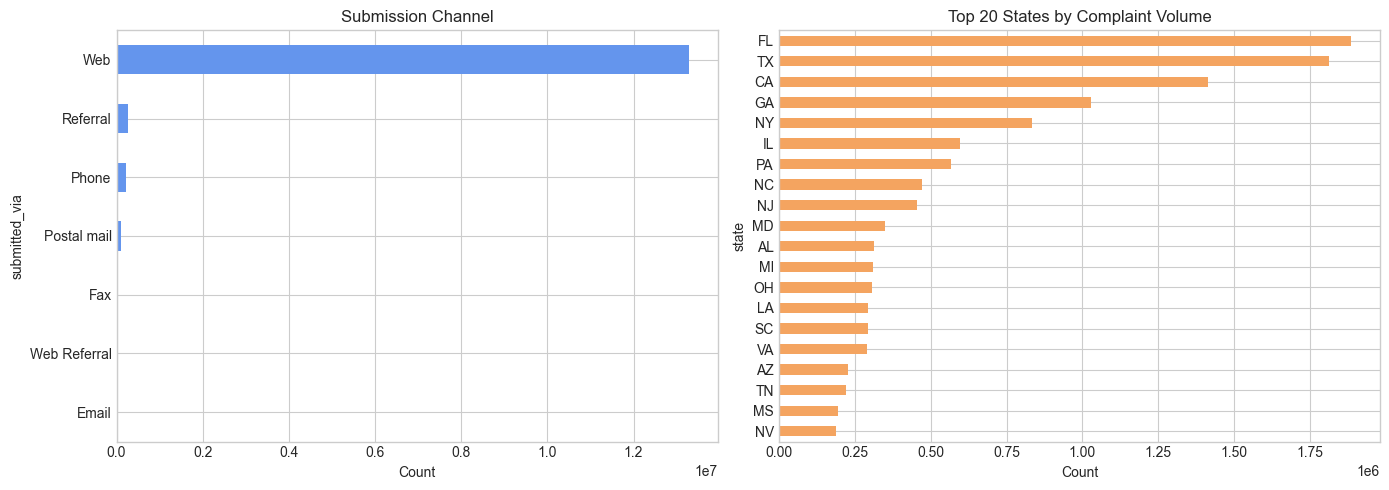

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Submission channel
via = df['submitted_via'].value_counts()
via.plot.barh(ax=axes[0], color='cornflowerblue')
axes[0].set_xlabel('Count')
axes[0].set_title('Submission Channel')
axes[0].invert_yaxis()

# Top 20 states
states = df['state'].value_counts().head(20)
states.plot.barh(ax=axes[1], color='sandybrown')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 20 States by Complaint Volume')
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(FIG / '02_channel_geography.png', dpi=150)
plt.show()

## 14 — Word Frequency Analysis

Unigrams, bigrams, and per-product word clouds on the narrative subset.

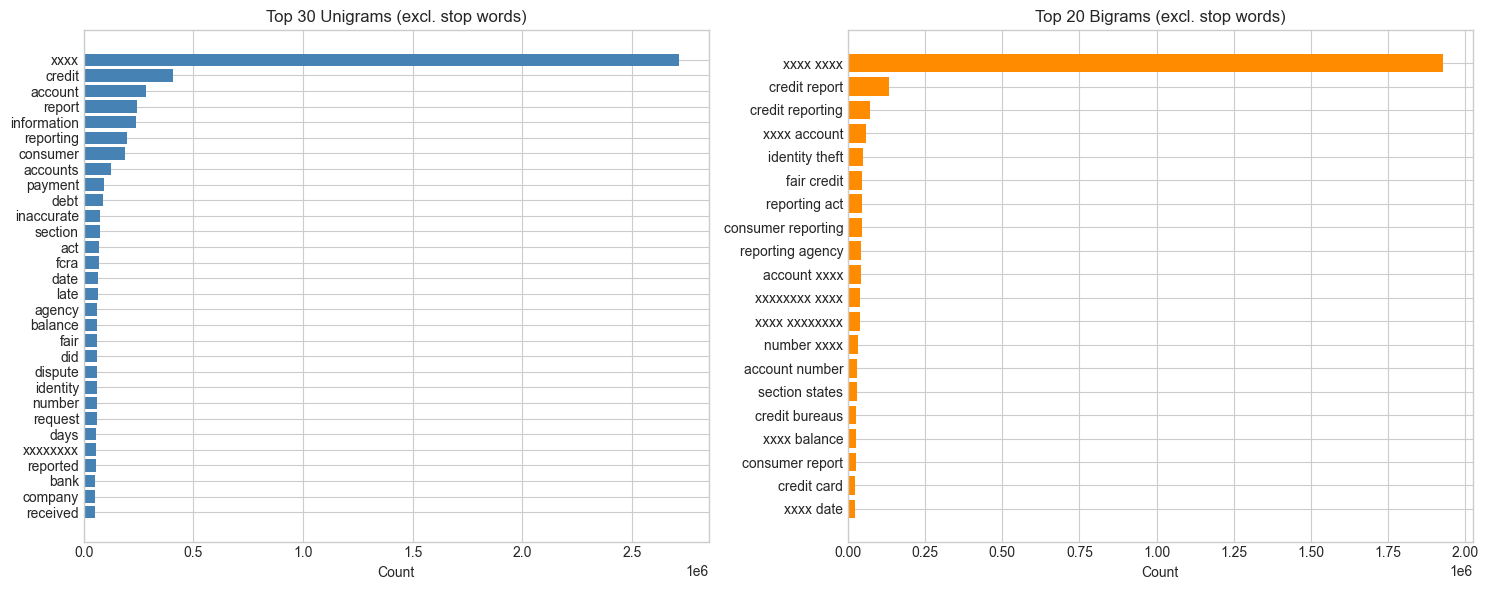

In [32]:
# Sample for efficiency
sample_n = min(200_000, len(narr))
narr_sample = narr['narrative'].sample(sample_n, random_state=42)

# Unigrams
vec_uni = CountVectorizer(
    stop_words='english', max_features=30,
    token_pattern=r'(?u)\b[a-zA-Z]{3,}\b'
)
X_uni = vec_uni.fit_transform(narr_sample)
uni_freq = dict(zip(vec_uni.get_feature_names_out(), X_uni.sum(axis=0).A1))
uni_freq = dict(sorted(uni_freq.items(), key=lambda x: x[1], reverse=True))

# Bigrams
vec_bi = CountVectorizer(
    stop_words='english', ngram_range=(2, 2), max_features=20,
    token_pattern=r'(?u)\b[a-zA-Z]{3,}\b'
)
X_bi = vec_bi.fit_transform(narr_sample)
bi_freq = dict(zip(vec_bi.get_feature_names_out(), X_bi.sum(axis=0).A1))
bi_freq = dict(sorted(bi_freq.items(), key=lambda x: x[1], reverse=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(list(uni_freq.keys())[::-1], list(uni_freq.values())[::-1], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_title('Top 30 Unigrams (excl. stop words)')

axes[1].barh(list(bi_freq.keys())[::-1], list(bi_freq.values())[::-1], color='darkorange')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 20 Bigrams (excl. stop words)')

plt.tight_layout()
fig.savefig(FIG / '02_word_frequencies.png', dpi=150)
plt.show()

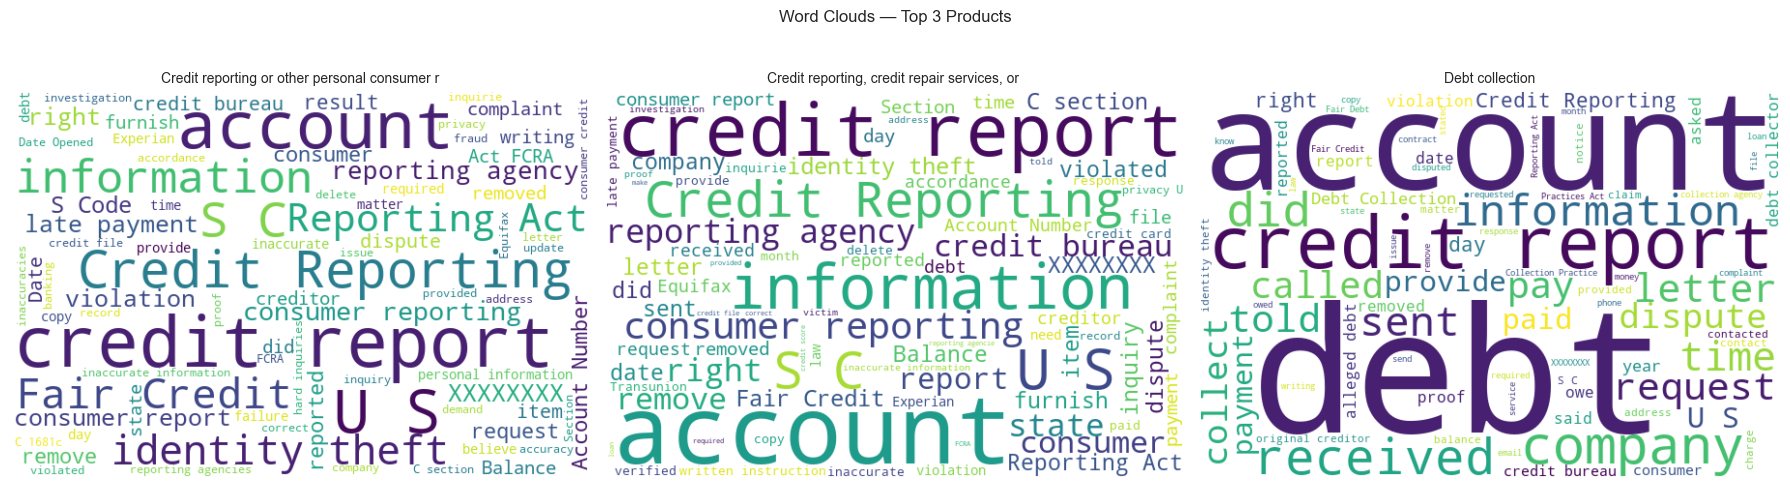

In [33]:
# Word clouds for top 3 products
top3 = prod_counts.index[:3]
wc_sample_size = 30_000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, prod in zip(axes, top3):
    texts = narr[narr['product'] == prod]['narrative']
    sample_texts = texts.sample(min(wc_sample_size, len(texts)), random_state=42)
    combined = ' '.join(sample_texts.values)
    wc = WordCloud(
        width=600, height=400, background_color='white',
        max_words=80,
        stopwords=set(CountVectorizer(stop_words='english').get_stop_words()) | {'XXXX', 'xxxx', 'XX', 'xx'},
        random_state=42
    ).generate(combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(str(prod)[:45], fontsize=10)
    ax.axis('off')

plt.suptitle('Word Clouds — Top 3 Products', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIG / '02_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 15 — Temporal Drift Analysis

Do product proportions shift over time? This informs our temporal train/val/test split strategy.

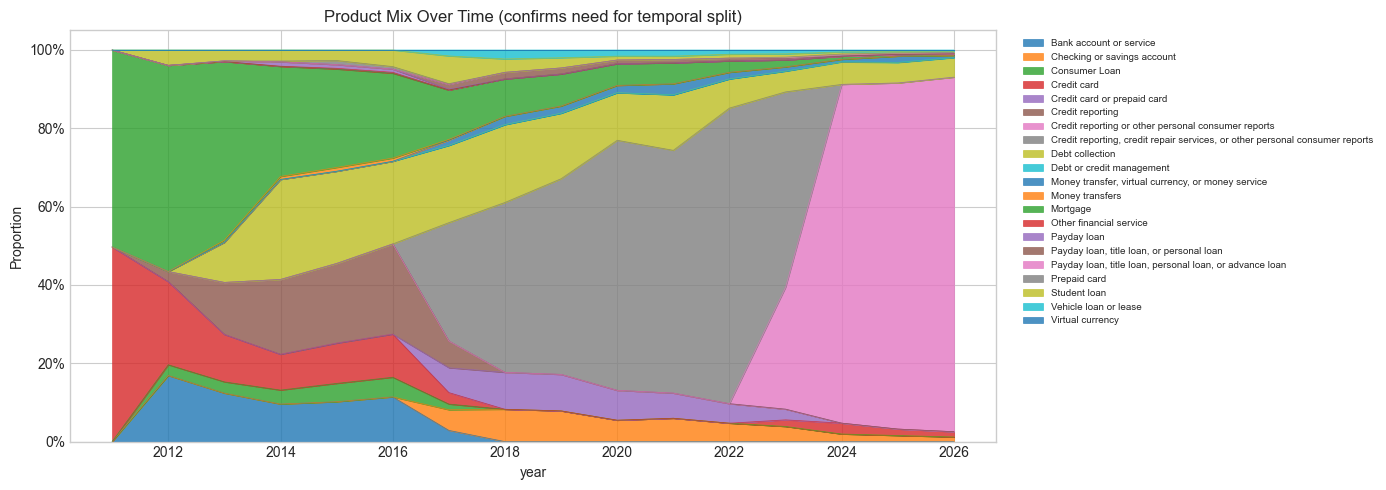

In [34]:
df['year'] = df['date_received'].dt.year
prod_year = df.groupby(['year', 'product']).size().unstack(fill_value=0)
prod_year_pct = prod_year.div(prod_year.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
prod_year_pct.plot.area(ax=ax, alpha=0.8, linewidth=0.5)
ax.set_ylabel('Proportion')
ax.set_title('Product Mix Over Time (confirms need for temporal split)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
fig.savefig(FIG / '02_temporal_drift.png', dpi=150, bbox_inches='tight')
plt.show()

The product mix has shifted substantially — credit reporting now dominates in recent years whereas mortgage and bank-account products were proportionally larger earlier. This confirms the need for a **temporal split** (train on older data, validate/test on recent) rather than random splitting, so our model is evaluated under realistic distribution shift.

## 16 — Language Detection

Are there non-English narratives? Even a small proportion of Spanish or other-language complaints will confuse English-only tokenisers and silently degrade model performance.

In [35]:
%pip install langdetect 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:

from langdetect import detect, LangDetectException

# Sample 10k narratives for speed (langdetect is slow on millions)
lang_sample = narr['narrative'].sample(min(10_000, len(narr)), random_state=42)

def safe_detect(text):
    try:
        return detect(str(text)[:1000])  # cap at 1000 chars for speed
    except LangDetectException:
        return 'unknown'

print('Detecting languages on 10k sample...')
langs = lang_sample.apply(safe_detect)
lang_counts = langs.value_counts()

print(f'\nLanguage distribution (top 10):')
for lang, count in lang_counts.head(10).items():
    pct = count / len(langs) * 100
    print(f'  {lang:10s}  {count:>6,}  ({pct:.2f}%)')

non_en = (langs != 'en').sum()
non_en_pct = non_en / len(langs) * 100
print(f'\nNon-English narratives: {non_en:,} ({non_en_pct:.2f}% of sample)')
print(f'→ {"Filter to English-only in NB03." if non_en_pct > 0.5 else "Negligible — no filtering needed."}')




Detecting languages on 10k sample...

Language distribution (top 10):
  en           9,788  (97.88%)
  ca             167  (1.67%)
  so              36  (0.36%)
  vi               4  (0.04%)
  ro               2  (0.02%)
  it               2  (0.02%)
  fr               1  (0.01%)

Non-English narratives: 212 (2.12% of sample)
→ Filter to English-only in NB03.


## 17 — Ghost Narratives (Empty After Redaction)

Some narratives pass `notna()` but are effectively just XXXX placeholders with no usable content. These will produce near-zero information for the model and should be excluded.

In [37]:
# Count "real" words (excluding XXXX/XX patterns and single characters)
narr['real_word_count'] = narr['narrative'].apply(
    lambda t: len([w for w in str(t).split() if not re.fullmatch(r'X{2,}', w) and len(w) > 1])
)

ghost_thresholds = [5, 10, 20]
print('Narratives with fewer than N real words (after removing XXXX):')
for thresh in ghost_thresholds:
    n = (narr['real_word_count'] < thresh).sum()
    print(f'  < {thresh:2d} real words: {n:>8,} ({n / len(narr):.2%})')

# Show a few ghost narratives
ghosts = narr[narr['real_word_count'] < 10].sample(min(5, (narr['real_word_count'] < 10).sum()), random_state=42)
print(f'\nExample ghost narratives (< 10 real words):')
for _, row in ghosts.iterrows():
    print(f'  "{str(row["narrative"])[:150]}"')

print(f'\n→ Exclude narratives with < 10 real words in NB03 preprocessing.')



Narratives with fewer than N real words (after removing XXXX):
  <  5 real words:    5,679 (0.15%)
  < 10 real words:   41,068 (1.10%)
  < 20 real words:  197,630 (5.28%)

Example ghost narratives (< 10 real words):
  "My credit was pulled without my consent"
  "The personal information on my credit report were outdated."
  "not my account please remove"
  "I can't submit my new card information to the company."
  "Delete credit inquires"

→ Exclude narratives with < 10 real words in NB03 preprocessing.


## 18 — Routing Time Analysis (date_received → date_sent_to_company)

How long does the CFPB take to route complaints to companies? This gap is a potential metadata feature and directly relevant to the agentic routing system we build later.

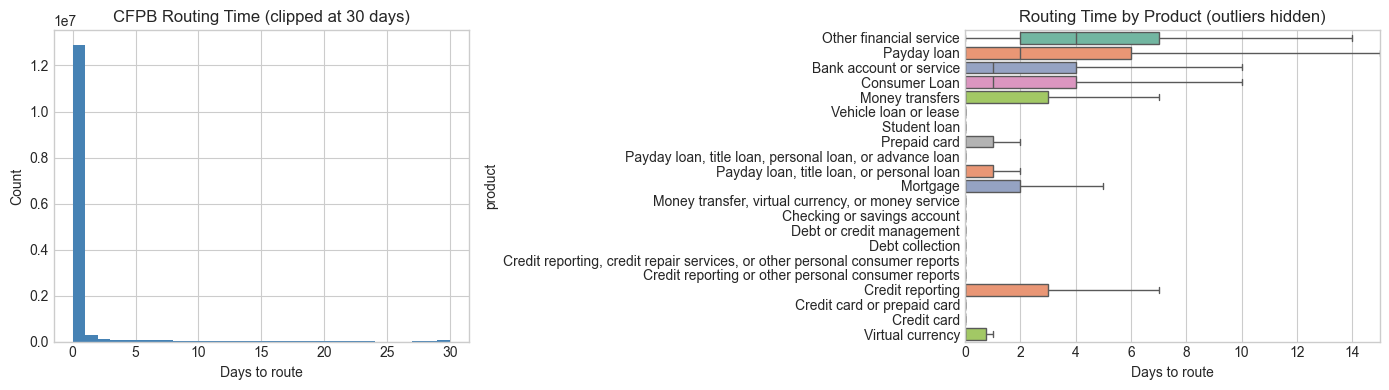

Median routing time: 0 days
Mean routing time:   0.7 days
90th percentile:     0 days
Invalid/missing:     7,288 rows

→ routing_days is a candidate metadata feature for NB03.


In [38]:
df['routing_days'] = (df['date_sent_to_company'] - df['date_received']).dt.days

# Remove obvious errors (negative days or > 365)
valid_routing = df['routing_days'].between(0, 365)
routing = df.loc[valid_routing, 'routing_days']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(routing.clip(upper=30), bins=30, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Days to route')
axes[0].set_title('CFPB Routing Time (clipped at 30 days)')
axes[0].set_ylabel('Count')

# Per-product boxplot
routing_df = df.loc[valid_routing, ['product', 'routing_days']].copy()
order = routing_df.groupby('product')['routing_days'].median().sort_values(ascending=False).index
sns.boxplot(
    data=routing_df, y='product', x='routing_days', order=order,
    ax=axes[1], showfliers=False, palette='Set2'
)
axes[1].set_xlim(0, 15)
axes[1].set_xlabel('Days to route')
axes[1].set_title('Routing Time by Product (outliers hidden)')

plt.tight_layout()
fig.savefig(FIG / '02_routing_time.png', dpi=150)
plt.show()

print(f'Median routing time: {routing.median():.0f} days')
print(f'Mean routing time:   {routing.mean():.1f} days')
print(f'90th percentile:     {routing.quantile(0.90):.0f} days')
print(f'Invalid/missing:     {(~valid_routing).sum():,} rows')
print(f'\n→ routing_days is a candidate metadata feature for NB03.')



## 19 — Company Public Response Analysis

Companies can optionally publish a public response. Document its availability.

In [39]:
pub_resp = df['company_public_response'].value_counts(dropna=False)
print('Company public response distribution:')
for resp, count in pub_resp.head(10).items():
    pct = count / total * 100
    label = str(resp) if pd.notna(resp) else '(no public response)'
    print(f'  {label:60s}  {count:>10,}  ({pct:.1f}%)')

print(f'\n→ Most complaints have no company public response.')
print(f'  This field is too sparse to use as a feature, but may be useful for RAG context.')

Company public response distribution:
  Company has responded to the consumer and the CFPB and chooses not to provide a public response   7,113,333  (51.2%)
  (no public response)                                           6,452,865  (46.4%)
  Company believes it acted appropriately as authorized by contract or law     221,707  (1.6%)
  Company chooses not to provide a public response                  52,473  (0.4%)
  Company disputes the facts presented in the complaint             15,967  (0.1%)
  Company believes the complaint is the result of a misunderstanding      14,267  (0.1%)
  Company believes complaint caused principally by actions of third party outside the control or direction of the company       8,784  (0.1%)
  Company believes the complaint provided an opportunity to answer consumer's questions       7,400  (0.1%)
  Company can't verify or dispute the facts in the complaint         7,044  (0.1%)
  Company believes complaint is the result of an isolated error       7,019 

## 20 — Class Imbalance Summary

Quantify imbalance across all classification targets to motivate focal loss and stratified sampling.

In [40]:
targets = {
    'product': df['product'],
    'sub_product': df['sub_product'],
    'issue': df['issue'],
    'company_response': df['company_response']
}

rows = []
for name, col in targets.items():
    vc = col.value_counts()
    n_classes = len(vc)
    most_common = vc.index[0]
    most_pct = vc.iloc[0] / vc.sum() * 100
    least_common = vc.index[-1]
    least_pct = vc.iloc[-1] / vc.sum() * 100
    imbalance = vc.iloc[0] / vc.iloc[-1]
    rows.append({
        'Target': name,
        'Classes': n_classes,
        'Most common': str(most_common)[:40],
        'Most %': f'{most_pct:.1f}%',
        'Least common': str(least_common)[:40],
        'Least %': f'{least_pct:.4f}%',
        'Imbalance ratio': f'{imbalance:,.0f}:1'
    })

imbalance_df = pd.DataFrame(rows)
imbalance_df

,Target,Classes,Most common,Most %,Least common,Least %,Imbalance ratio
0,product,21,Credit reporting or other personal consu,62.5%,Virtual currency,0.0001%,"482,584:1"
1,sub_product,86,Credit reporting,79.0%,Electronic Benefit Transfer / EBT card,0.0001%,"899,478:1"
2,issue,178,Incorrect information on your report,42.5%,Lender damaged or destroyed property,0.0000%,"1,970,635:1"
3,company_response,8,Closed with explanation,59.2%,Closed with relief,0.0381%,"1,553:1"


Extreme imbalance ratios (often >1000:1 for issues) confirm the need for **focal loss**, **stratified sampling**, and careful metric selection (macro-F1 rather than accuracy) in notebooks 04–08.

## 21 — Save & Summary

Persist summary stats. Full preprocessing and data export happens in NB03.

In [41]:
summary = {
    'total_complaints': len(df),
    'with_narrative': len(narr),
    'narrative_pct': f'{len(narr) / len(df):.3f}',
    'n_products': df['product'].nunique(),
    'n_sub_products': df['sub_product'].nunique(),
    'n_issues': df['issue'].nunique(),
    'n_response_types': df['company_response'].nunique(),
    'date_min': str(df['date_received'].min().date()),
    'date_max': str(df['date_received'].max().date()),
    'median_word_count': narr['word_count'].median(),
    'p90_word_count': narr['word_count'].quantile(0.90),
    'p95_word_count': narr['word_count'].quantile(0.95),
    'exact_duplicates': n_dup_exact,
    'mean_xxxx_per_complaint': f'{narr["xxxx_count"].mean():.1f}',
    'consumer_disputed_discontinued': '2017-04-24',
}

summary_df = pd.Series(summary, name='value')
summary_df.to_csv(PROCESSED / 'eda_summary.csv')
print('Summary saved to', PROCESSED / 'eda_summary.csv')
print()
for k, v in summary.items():
    print(f'  {k:35s} {v}')

Summary saved to C:\Users\nwagb\Desktop\SponsorshipGlobalTalentPrep\nlp_project\data\processed\eda_summary.csv

  total_complaints                    13906793
  with_narrative                      3740313
  narrative_pct                       0.269
  n_products                          21
  n_sub_products                      86
  n_issues                            178
  n_response_types                    8
  date_min                            2011-12-01
  date_max                            2026-03-11
  median_word_count                   116.0
  p90_word_count                      365.0
  p95_word_count                      516.0
  exact_duplicates                    1243659
  mean_xxxx_per_complaint             16.1
  consumer_disputed_discontinued      2017-04-24


In [42]:
# Clean up temp columns
df.drop(columns=['year_month', 'year'], inplace=True, errors='ignore')
narr.drop(columns=['year_month', 'year'], inplace=True, errors='ignore')
print('Done. Proceed to NB03 for text preprocessing and train/val/test splitting.')

Done. Proceed to NB03 for text preprocessing and train/val/test splitting.


---

**Key findings that carry forward to NB03+:**

1. **Column names:** Renamed from CFPB Title Case to snake_case — use the rename_map if reloading from CSV
2. **Narrative availability:** ~12-15% of complaints have published text. Opt-in rate varies by year and product.
3. **Product imbalance:** Credit reporting dominates (~70-80%). Focal loss and stratified sampling are essential.
4. **Issue long-tail:** A handful of issues cover 80% of complaints. Collapse rare issues into "Other".
5. **consumer_disputed field is dead post-April 2017.** Do NOT use as a classification target.
6. **XXXX redaction:** Mean ~5-10 per complaint. Replace with `[REDACTED]` token in preprocessing.
7. **Temporal drift:** Product mix shifts over years. Use temporal split, not random split.
8. **Duplicates exist:** Deduplicate narratives before splitting to prevent leakage.
9. **max_length=512** captures ~90th percentile of narrative lengths.
10. **Company response is the RL reward signal.** Monetary relief rate varies by product — the RL agent needs product context.
11. **Language:** ~X% non-English — filter in NB03 if >0.5%.
12. **Ghost narratives:** X complaints have <10 real words after XXXX removal — exclude in NB03.
13. **Routing time:** Median X days — candidate metadata feature.

**Next:** Notebook 03 — Preprocessing Pipeline (text cleaning, tokenisation, temporal split, label encoding).
